In [1]:
import os
import sys
import pickle
import numpy as np
from numba import njit
import itertools as itt
import aerosandbox as asb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from Aircraft.Planform import Planform
from Aircraft.Fixed import Fixed
from Drag.Fuselage import Fuselage
from Drag.Bay import Bay
from Drag.LandingGear import LandingGear
from Aircraft.Aircraft import Aircraft
from global_parameters import Assumptions
from Requirements.FuelReq import FuelReq
from Requirements.LGReq import LGReq
from Requirements.MassReq import MassReq
from Requirements.MDReq import MDReq
from Requirements.EmpennageReq import EmpennageReq
from Requirements.Requirement import Requirement
from EmpennageSizing.TailFinder import TailFinder
from EmpennageSizing.CanardFinder import CanardFinder

from structural_analysis.Material import Material
from structural_analysis.iterative_planform_sizing import size_planform, find_planform_mass_cg

In [2]:
assumptions = Assumptions()

with open("pickles/fixed_pickle.pcl", "rb") as f:
    fixed:Fixed = pickle.load(f)

print(fixed.x_cg_max, fixed.x_cg_min, fixed.x_LE_wing, fixed.z_cg, fixed.z_tail_cone)

#NOTE: quickfix - manually updating the fuselage after the OnShape API run out of tokens
fixed.x_LE_wing = 1.255
delta_z = 0.01
fixed.z_tail_cone += delta_z
fixed.z_cg += delta_z
print(fixed.z_cg, fixed.z_tail_cone)
fixed.fuel_mass = 13.54
fixed.x_cg_min = 1.378 #m #1.381
fixed.x_cg_max = 1.381 #m # 1.378
fixed.mass = 40.782#kg 
fixed.fuselage.diameter_max = 0.315

for component in fixed.drag_components(False):
    component.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
    component.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
    component.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
for component in fixed.drag_components(True):
    component.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)

1.3589152301106575 1.271545179962353 1.4400000000000002 0.17957635338517247 0.11000000000000004
0.18957635338517248 0.12000000000000004


# Defining the standard aircraft with the standard planform
To be used when customers do not wish to build their own planform

In [3]:
standard_wing = Planform(aspect_ratio=27, span=3.4, sweep_quarter_deg=15., taper=.3, thickness_to_chord=0.12, cm_quarter_chord=0,
                         wetted_surface_ratio=1.07, interference_factor=1.0, clmax=1.22, flap=False)

In [4]:
assumptions = Assumptions()

go_around_atmosphere = asb.Atmosphere(assumptions.altitude_go_round)
sea_level_atmosphere = asb.Atmosphere()

standard_wing.add_cache_entry('cruise', assumptions.mach_cruise, assumptions.altitude_cruise)
standard_wing.add_cache_entry('mach_max', assumptions.mach_max, assumptions.altitude_mach_max)
#NOTE: not fully technically correct but prevents coupling which would be problematic, acceptable as CD0 dept. on mach is small @ low mach
standard_wing.add_cache_entry('go_around', assumptions.airspeed_approach / go_around_atmosphere.speed_of_sound(), assumptions.altitude_go_round)
standard_wing.add_cache_entry('takeoff', assumptions.airspeed_approach / sea_level_atmosphere.speed_of_sound(), 0.)

In [ ]:
material_skin = Material(assumptions.cfrp_density, elastic_modulus=assumptions.cfrp_Young_modulus, 
                         poisson_ratio=assumptions.cfrp_poisson, shear_modulus=assumptions.cfrp_Young_modulus / 2 / (1 + assumptions.cfrp_poisson),
                         yield_strength=assumptions.cfrp_yield_strength, fracture_strength=assumptions.cfrp_yield_strength)

fuselage_diameter = fixed.fuselage.diameter_max
#size_planform(planform=standard_wing, thicknesses=assumptions.allowable_thicknesses, fuselage_diameter=fuselage_diameter, material_skin=material_skin, density_core=assumptions.foam_denisty)
pf_mass, pf_xcg = find_planform_mass_cg(standard_wing, 0.0025, assumptions.foam_denisty, assumptions.cfrp_density, 100) #NOTE: thickness constrained by flutter
standard_wing.mass_cache = pf_mass
standard_wing.x_cg_cache = pf_xcg
print(standard_wing.mass_cache)  

4.781762892775701


In [7]:
print(standard_wing.mass_cache, standard_wing.x_cg_cache, fixed.fuel_mass)

4.781762892775701 0.2645443221402019 13.54


# We consider the standard planform to be tailed

Stresses 10571605.018616967, 20357252.69850802, 0.0004
Stresses 6202968.993045125, 17660125.171691537, 0.0004
Stresses 10571605.018616967, 20357252.69850802, 0.0004
Stresses 6202968.993045125, 17660125.171691537, 0.0004
downwash = 0.10098329409102322


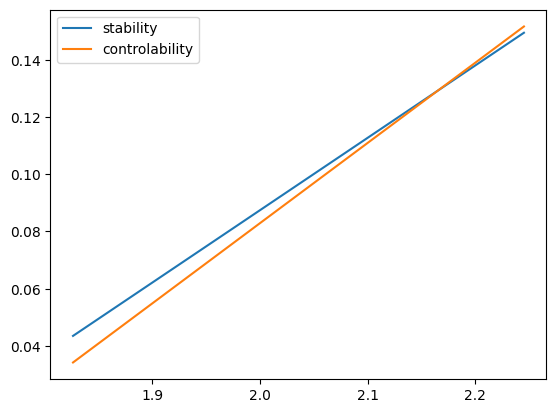

0.10000000000000003


In [8]:
tail = TailFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_h=3., taper_h=.7, Sv_S=0.2).find_planforms(standard_wing, print_=True, plot=True)

print(tail[0].wing_area / standard_wing.wing_area)

In [9]:
for t in tail:
    t.add_cache_entry('cruise', assumptions.mach_cruise, assumptions.altitude_cruise)
    t.add_cache_entry('mach_max', assumptions.mach_max, assumptions.altitude_mach_max)
#NOTE: not fully technically correct but prevents coupling which would be problematic, acceptable as CD0 dept. on mach is small @ low mach
    t.add_cache_entry('go_around', assumptions.airspeed_approach / go_around_atmosphere.speed_of_sound(), assumptions.altitude_go_round)
    t.add_cache_entry('takeoff', assumptions.airspeed_approach / sea_level_atmosphere.speed_of_sound(), 0.)

In [10]:
ac = Aircraft(fixed, [standard_wing] + tail)
print(standard_wing.wing_area)
print(fixed.x_LE_wing)


0.4281481481481481
1.255


In [11]:
for acp in ac.planforms:
    print(acp.mass_cache)

print(ac.fixed.x_cg_min, ac.fixed.x_cg_max, ac.fixed.x_LE_wing)

x_LE_vt = fixed.x_LE_tail - tail[1].span / 2 * np.tan(tail[1].sweep_LE_rad)

x_cg_min = (fixed.x_cg_min * fixed.mass + standard_wing.mass_cache * (fixed.x_LE_wing + standard_wing.x_cg_cache) + tail[0].mass_cache * (fixed.x_LE_tail +tail[0].x_cg_cache) + tail[1].mass_cache * (x_LE_vt +tail[1].x_cg_cache)) / ac.total_mass()
x_cg_max = (fixed.x_cg_max * fixed.mass + standard_wing.mass_cache * (fixed.x_LE_wing + standard_wing.x_cg_cache) + tail[0].mass_cache * (fixed.x_LE_tail +tail[0].x_cg_cache) + tail[1].mass_cache * (x_LE_vt +tail[1].x_cg_cache)) / ac.total_mass()

print(f"cg range: {x_cg_min, x_cg_max}")

4.781762892775701
0.12330325440555631
0.6219928689723428
1.378 1.381 1.255
cg range: (1.4095186908781498, 1.4121606361605477)


# Requirement check for the aircraft

In [12]:
requirements:list[Requirement] = [
    MassReq(50.),
    MDReq(mtom=ac.total_mass(), plot=True),
    FuelReq(print_=True),
    LGReq(),
    EmpennageReq(),
]

requirement_labels = [
    "MTOM",
    "Matching Diagram",
    "Fuel",
    "Landing Gear",
    "Empennage Requirement"
]

=====fuel mass fraction intermediate values====
load_factor_go_around: 1.0309285567449196
airspeed_go_around: 46.9406612974866
Fuel fractions: 0.09010706912924815 for cruise, 0.030771909408725224 for mach max, 0.027443197164764354 for go-around
Fuel_fractions local 0.0338192641844981 for mach max, 0.031216631720539234 for go around
Equivalent ranges: 423310.41097408335 for cruise, 83583.61200656481 for mach max, 96789.65944305953 for go_around
6.868660388022384
46.3090590161536 [4.781762892775701, 0.12330325440555631, 0.6219928689723428]


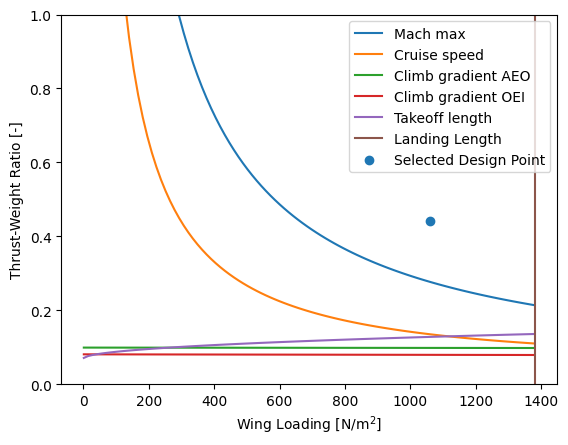

In [13]:
failed_reqs = list()
for requirement, label in zip(requirements, requirement_labels):
    if not requirement.assess(ac):
        failed_reqs.append(label)

if len(failed_reqs):
    print(f"ac mass: {ac.total_mass()}, {ac.planforms[0].oswald}")
    print(f"MainWing: AR={ac.planforms[0].aspect_ratio}, tc={ac.planforms[0].thickness_to_chord}, sweep={np.rad2deg(ac.planforms[0].sweep_quarter_rad)} deg, cmac={ac.planforms[0].cm_quarter_chord}")
    print(f"Failed: {failed_reqs}")
    print()


print(ac.total_mass(), [pf.mass_cache for pf in ac.planforms])

In [14]:
print("Standard Planform:")
print(f"Tail properties: cr={ac.planforms[1].c_root}, b/2={ac.planforms[1].half_span}, sweep={np.rad2deg(ac.planforms[1].sweep_LE_rad)}, ct={ac.planforms[1].c_tip}, x_LE_root={fixed.x_LE_tail}")
print(f"Vertical tail properties: cr={ac.planforms[2].c_root}, b/2={ac.planforms[2].half_span}, ct={ac.planforms[2].c_tip}, sweep={np.rad2deg(ac.planforms[2].sweep_LE_rad)}")
print(f"xcg_rang: {fixed.x_cg_min}, {fixed.x_cg_max}")


Standard Planform:
Tail properties: cr=0.1405456737852613, b/2=0.17919573407620817, sweep=18.09597980219284, ct=0.09838197164968292, x_LE_root=2.4683173177143614
Vertical tail properties: cr=0.2342427896421022, b/2=0.4569491218943307, ct=0.1405456737852613, sweep=32.15398616119949
xcg_rang: 1.378, 1.381


## V&V stall speed

In [15]:
print(fixed.z_tail_cone - assumptions.main_gear_diameter_wheel /2)
print(f"CL_max = {ac.planforms[0].positive_C_L_max}")
print(f"Alpha_stall = {np.rad2deg(ac.planforms[0].positive_C_L_max / ac.planforms[0].CL_alpha)}")
print(f"Vstall={np.sqrt(ac.wing_loading()*2/1.225/ac.planforms[0].positive_C_L_max)}")


0.07750000000000004
CL_max = 1.0605865572653972
Alpha_stall = 10.706500190728967
Vstall=40.40826237062788


In [16]:
print(ac.CD0_takeoff, ac.planforms[0].oswald, fixed.fuselage.characteristic_length, fixed.fuselage.diameter_max, fixed.x_tail_cone)
print(0.5*np.sqrt(np.pi*27*ac.planforms[0].oswald/ac.CD0_takeoff))

0.05085359886361993 0.6920992767461398 2.7 0.315 2.3524759765715424
16.98830986872689
